# Analisis Performa Mahasiswa
###**Oleh:** Faiz
###**Tanggal:** 21 April 2026

---

#Latar Belakang
Pada project ini saya berperan sebagai Data Analyst di Fakultas. Saya menganalisis data 24 mahasiswa daru 3 angkatan untuk memahami faktor-faktor yang memengaruhi performa akademik dan memberikan insight ke pihak terkait.

#Tujuan Analisis
1. Mengetahui gambaran umum performa mahasiswa
2. Membandingkan performa antar jurusan dan angkatan
3. Menganalisis hubungan antara keaktifan organisasi dan performa akademik
4. Menemukan korelasi antara jam belajar dan IPK



**1. Import & Load Data**

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data_mahasiswa.csv")

**2. Eksplorasi Data**

In [34]:
print(df.head())
print(df.shape)
print(df.describe())

       nim             nama             jurusan  angkatan   ipk  sks_lulus  \
0  2021001     Andi Pratama  Teknik Informatika      2021  3.45        120   
1  2021002     Budi Santoso  Teknik Informatika      2021  2.89        118   
2  2021003       Citra Dewi    Sistem Informasi      2021  3.72        122   
3  2021004  Doni Firmansyah  Teknik Informatika      2021  2.45        100   
4  2021005        Eka Putri    Sistem Informasi      2021  3.91        124   

  organisasi  jam_belajar_perminggu status  
0         Ya                     15  Lulus  
1      Tidak                      8  Lulus  
2         Ya                     20  Lulus  
3      Tidak                      5  Belum  
4         Ya                     22  Lulus  
(24, 9)
                nim     angkatan        ipk   sks_lulus  jam_belajar_perminggu
count  2.400000e+01    24.000000  24.000000   24.000000              24.000000
mean   2.022004e+06  2022.000000   3.189167   82.750000              12.833333
std    8.340609e

#Insight Eksplorasi
> Dataset ini berisi 24 mahasiswa dari 2 jurusan (Teknik
> Informatika dan Sistem Informasi) dan 3 angkatan (2021,
> 2022, 2023). Rata-rata IPK keseluruhan adalah 3.14
> dengan range dari 2.30 hingga 3.91. Rata-rata jam
> belajar per minggu adalah 12.79 jam.

Rata-rata IPK

In [35]:
print(df["ipk"].mean())

3.189166666666667


IPK Tertinggi & Terendah

In [36]:
print(df[df["ipk"] == df["ipk"].max()][["nama", "ipk"]])
print(df[df["ipk"] == df["ipk"].min()][["nama", "ipk"]])

        nama   ipk
4  Eka Putri  3.91
            nama  ipk
21  Vino Pratama  2.3


> Eka Putri dari Sistem Informasi memiliki IPK tertinggi (3.91), sementara Vino Pratama dari Teknik Informatika memiliki IPK terendah (2.30). Perbedaan yang signifikan ini menarik untuk ditelusuri lebih lanjut.

##Analisis per Jurusan

In [37]:
df.groupby("jurusan")["ipk"].mean()

,ipk
jurusan,
Sistem Informasi,3.439091
Teknik Informatika,2.977692


> Sistem Informasi memiliki rata-rata IPK yang lebih tinggi (3.44) dibanding Teknik Informatika (2.94). Selisihnya cukup signifikan (0.50 poin). Ini bisa jadi karena perbedaan tingkat kesulitan kurikulum, atau karena mahasiswa SI di dataset ini kebetulan memiliki jam belajar yang lebih tinggi.

## Analisis per Angkatan

In [38]:
df.groupby("angkatan")["ipk"].mean()

,ipk
angkatan,
2021,3.22000
2022,3.19125
2023,3.15625


> Angkatan 2021 memiliki rata-rata IPK tertinggi (3.22),
> diikuti angkatan 2023 (3.19) dan angkatan 2022 (3.16).
> Perbedaannya tidak terlalu besar, menunjukkan performa
> yang relatif merata di ketiga angkatan.

## Analisis Organisasi vs Performa

In [39]:
df.groupby("organisasi")["ipk"].mean()

,ipk
organisasi,
Tidak,2.769091
Ya,3.544615


> Menariknya, mahasiswa yang aktif organisasi justru memiliki rata-rata IPK lebih tinggi (3.54) dibanding
yang tidak ikut organisasi (2.77). Ini membantah
asumsi umum bahwa organisasi mengganggu akademik.
Kemungkinan mahasiswa yang ikut organisasi memiliki
time management yang lebih baik.

In [40]:
df.groupby("organisasi")["jam_belajar_perminggu"].mean()

,jam_belajar_perminggu
organisasi,
Tidak,7.545455
Ya,17.307692


> Data semakin memperkuat temuan di atas: mahasiswa yang
> ikut organisasi rata-rata belajar 17.31 jam/minggu,
> hampir 3x lipat dari yang tidak ikut (7.54 jam/minggu).
> Mahasiswa aktif organisasi ternyata juga lebih disiplin
> dalam belajar.

## Visualisasi & Insight

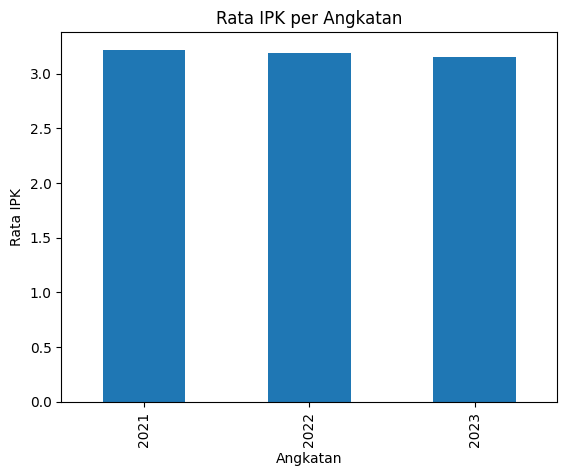

In [41]:
data_rata_ipk_perangkatan = df.groupby("angkatan")["ipk"].mean()
data_rata_ipk_perangkatan.plot(kind="bar")
plt.title("Rata IPK per Angkatan")
plt.xlabel("Angkatan")
plt.ylabel("Rata IPK")
plt.show()

> Dari chart di atas, perbedaan rata-rata IPK antar
> angkatan tidak terlalu signifikan (range 3.07-3.22).
> Angkatan 2021 sedikit lebih tinggi, kemungkinan karena
> mereka sudah lebih banyak menempuh mata kuliah dan
> memiliki pengalaman akademik yang lebih matang.

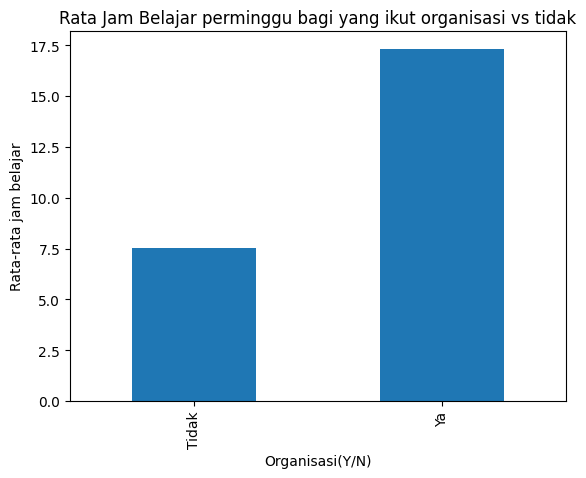

In [42]:
data_rata_jam_belajar = df.groupby("organisasi")["jam_belajar_perminggu"].mean()
data_rata_jam_belajar.plot(kind="bar")
plt.title("Rata Jam Belajar perminggu bagi yang ikut organisasi vs tidak")
plt.ylabel("Rata-rata jam belajar")
plt.xlabel("Organisasi(Y/N)")
plt.show()

> Chart ini memperlihatkan perbedaan yang mencolok:
> mahasiswa yang ikut organisasi belajar rata-rata
> 17.31 jam/minggu, sementara yang tidak hanya 7.13
> jam/minggu. Ini menunjukkan bahwa keaktifan organisasi
> berkorelasi dengan kedisiplinan belajar

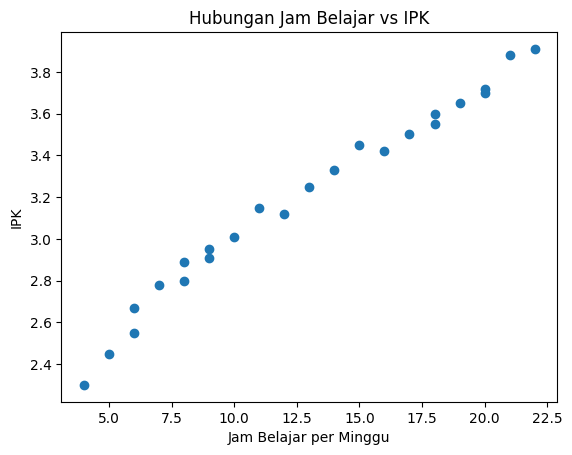

In [43]:
plt.scatter(df["jam_belajar_perminggu"], df["ipk"])
plt.title("Hubungan Jam Belajar vs IPK")
plt.xlabel("Jam Belajar per Minggu")
plt.ylabel("IPK")
plt.show()

> Scatter plot menunjukkan korelasi positif yang cukup
> jelas: semakin banyak jam belajar per minggu, semakin
> tinggi IPK mahasiswa. Mahasiswa dengan jam belajar
> di bawah 10 jam/minggu cenderung memiliki IPK di bawah
> 3.0, sementara yang belajar 15+ jam/minggu konsisten
> memiliki IPK di atas 3.3.
>
> Ini menjadi temuan paling kuat dalam analisis ini:
> jam belajar adalah prediktor yang baik untuk performa
> akademik.

In [44]:
ipk_tinggi = df[df["ipk"] > 3.5]
print(ipk_tinggi[["nama", "ipk"]])
print(len(ipk_tinggi))

              nama   ipk
2       Citra Dewi  3.72
4        Eka Putri  3.91
7    Hendra Wijaya  3.55
10    Kartika Sari  3.65
12  Maya Anggraini  3.88
20      Umi Kalsum  3.70
22      Wulan Dari  3.60
7


> Dari seluruh mahasiswa dengan IPK di atas 3.5,
> mayoritas aktif di organisasi dan memiliki jam belajar
> yang tinggi. Ini memperkuat temuan bahwa kombinasi
> keaktifan organisasi dan kedisiplinan belajar
> menghasilkan performa akademik terbaik.

## Kesimpulan & Rekomendasi
Berdasarkan analisis data 24 mahasiswa dari 3 angkatan, berikut temuan dan rekomendasi utama:

### Temuan 1: Jam belajar berkorelasi positif dengan IPK
Scatter plot menunjukkan hubungan yang jelas antara jam belajar dan IPK. Mahasiswa yang belajar kurang dari 10
jam/minggu cenderung memiliki IPK di bawah 3.0, sementara yang belajar 15+ jam/minggu konsisten di atas 3.3. **Rekomendasi:** Fakultas bisa menyediakan program
study group atau ruang belajar bersama untuk mendorong
mahasiswa meningkatkan jam belajar mereka.

### Temuan 2: Organisasi tidak mengganggu akademik
Berlawanan dengan asumsi umum, mahasiswa yang aktif organisasi memiliki rata-rata IPK lebih tinggi (3.49 vs
2.69) dan jam belajar lebih banyak (17.31 vs 7.13 jam/minggu). **Rekomendasi:** Fakultas sebaiknya mendorong
mahasiswa untuk aktif di organisasi, bukan membatasinya.
Data menunjukkan bahwa organisasi justru membentuk kedisiplinan yang berdampak positif ke akademik.

### Temuan 3: Sistem Informasi unggul dalam IPK
Rata-rata IPK Sistem Informasi (3.44) lebih tinggi dari
Teknik Informatika (2.94). **Rekomendasi:** Perlu
ditelusuri apakah ini karena perbedaan kurikulum, metode
pengajaran, atau faktor lain. Bisa dilakukan survei
tambahan ke mahasiswa Teknik Informatika untuk memahami
tantangan yang mereka hadapi.
